# New adaptive point selection — robust fitting with sigma-clipping

## Problems with the original RSS-based sweep

**Problem 1 — bias toward minimum points:**  
Plain RSS grows as you add more points (more terms in the sum), so the optimizer always prefers using fewer points. We need a metric that *normalizes* by point count.

**Problem 2 — physically anomalous points:**  
Some points inside an injection span deviate from the exponential decay due to plasma instabilities. We know the true decay *must* be exponential (physics), so those points are measurement artifacts — not signal — and should be excluded.

## Proposed solutions

| Problem | Solution |
|---|---|
| RSS min-points bias | Use **reduced χ²** = RSS / (n − 2). Normalizes by degrees of freedom; adding a well-fitting point can only improve the score. |
| Anomalous / outlier points | **Iterative sigma-clipping**: fit on all injection points → compute residuals → remove points where \|r\| > k·MAD → refit → repeat until stable. Uses `scipy.optimize.least_squares` with `loss='soft_l1'` for the initial robust estimate. |

MAD (median absolute deviation) is the standard robust scatter estimator used in experimental physics and astronomy pipelines.


In [1]:
"""Cell 1 — Setup: imports, project root, load discharge, detect injections."""
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, curve_fit

# --- locate project root so pha_lib is importable ---
def _find_root(start: Path) -> Path:
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "pha_lib").exists():
            return p
    raise FileNotFoundError("pha_lib not found")

ROOT = _find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pha_lib import io
from pha_lib.timetrace import integrate_energy_window
from pha_lib.discharges import detect_injections

# --- parameters ---
DISCHARGE_DIR = ROOT / "data" / "discharges" / "2025-04-29--10-19"
CHANNEL_ID    = 2
LINE_E        = 6660.0   # eV
HALF_W        = 60.0     # eV half-window

# --- load discharge and detect injections ---
discharge  = io.load_test_folder(DISCHARGE_DIR, discharge_id="2025-04-29--10-19")
channel    = discharge.channels[CHANNEL_ID]
trace      = integrate_energy_window(channel, LINE_E, HALF_W)
injections = detect_injections(trace, LINE_E)

print(f"Loaded: {discharge.discharge_id}")
print(f"Channel {CHANNEL_ID}: {len(injections)} injection(s) detected")
for inj in injections:
    print(f"  #{inj.injection_no}  frames {inj.start_frame}..{inj.finish_frame}  "
          f"(span={inj.finish_frame - inj.start_frame})")

# work on the first injection
injection = injections[0]
print(f"\nWorking on injection #{injection.injection_no}  "
      f"(start={injection.start_frame}, finish={injection.finish_frame})")


Loaded: 2025-04-29--10-19
Channel 2: 4 injection(s) detected
  #1  frames 98..106  (span=8)
  #2  frames 145..153  (span=8)
  #3  frames 192..200  (span=8)
  #4  frames 279..287  (span=8)

Working on injection #1  (start=98, finish=106)


In [2]:
"""Cell 2 — Core fitting helpers.

fit_sigma_clip():
  1. Fit the full injection span with soft_l1 robust loss (initial robust estimate).
  2. Compute residuals; mark outliers where |r| > sigma_thresh * MAD.
  3. Refit on inliers only (ordinary least-squares).
  4. Repeat until the inlier set stops changing or max_iter is reached.

Returns a dict with fit params, covariance, inlier mask, and quality metrics.
"""

_MAD_SCALE = 1.4826   # makes MAD equivalent to 1-sigma for Gaussian noise


def _exp_model(t, A, tau, t_0, C_bg):
    """Exponential decay: A * exp(-(t - t_0) / tau) + C_bg."""
    return A * np.exp(-(t - t_0) / tau) + C_bg


def _initial_guess(y_fit, t_0, C_bg):
    """Simple initial guess: A from first point above background, tau=1."""
    A0 = max(float(y_fit[0] - C_bg), 1.0)
    return [A0, 1.0]


def fit_sigma_clip(
    trace,
    injection,
    sigma_thresh: float = 2.5,
    max_iter: int = 10,
    min_inliers: int = 4,
) -> dict:
    """Robust iterative sigma-clipping fit over the full injection span.

    Parameters
    ----------
    trace          : TimeTrace with .frame_numbers and .values
    injection      : Injection with .start_frame and .finish_frame
    sigma_thresh   : outlier threshold in units of MAD
    max_iter       : maximum number of sigma-clip iterations
    min_inliers    : minimum inliers required to keep a fit valid

    Returns
    -------
    dict with keys:
      success, A, tau, t_0, C_bg, A_err, tau_err,
      inlier_mask (bool array over injection span),
      n_total, n_inliers, inlier_fraction,
      rss_inliers, rmse_inliers, reduced_chi2,
      message, iterations
    """
    fn = trace.frame_numbers
    v  = trace.values

    # t_0 fixed convention: second point of burst
    t_0   = float(injection.start_frame + 1)
    C_bg  = float(np.median(v))

    # --- locate the injection span in the trace ---
    try:
        start_idx = int(np.where(fn == int(t_0))[0][0])
    except IndexError:
        return _fail(f"t_0={int(t_0)} not in trace", t_0, C_bg)

    try:
        end_idx = int(np.where(fn == int(injection.finish_frame))[0][0]) + 1
    except IndexError:
        end_idx = len(fn)
    end_idx = max(end_idx, start_idx + min_inliers)

    t_all = fn[start_idx:end_idx].astype(float)
    y_all = v[start_idx:end_idx].astype(float)
    n_total = len(t_all)

    if n_total < min_inliers:
        return _fail(f"injection span too short ({n_total} pts)", t_0, C_bg)

    # --- Step 1: robust seed fit using soft_l1 loss (downweights outliers) ---
    def _res(params, t, y):
        # residuals for least_squares (not squared; it squares internally)
        A, tau = params
        return _exp_model(t, A, tau, t_0, C_bg) - y

    p0 = _initial_guess(y_all, t_0, C_bg)
    try:
        seed = least_squares(
            _res, p0,
            args=(t_all, y_all),
            loss='soft_l1',          # built-in robust loss — reduces outlier pull
            f_scale=float(np.std(y_all)) or 1.0,
            bounds=([0, 0.01], [np.inf, np.inf]),
            max_nfev=5000,
        )
        A_seed, tau_seed = seed.x
    except Exception:
        # fall back to plain initial guess if robust seed fails
        A_seed, tau_seed = p0

    # --- Step 2: iterative sigma-clipping on inlier set ---
    inlier_mask = np.ones(n_total, dtype=bool)

    for iteration in range(max_iter):
        t_in = t_all[inlier_mask]
        y_in = y_all[inlier_mask]

        if len(t_in) < min_inliers:
            # not enough inliers to continue
            break

        try:
            popt, pcov = curve_fit(
                lambda t, A, tau: _exp_model(t, A, tau, t_0, C_bg),
                t_in, y_in,
                p0=[A_seed, tau_seed],
                maxfev=5000,
            )
        except Exception:
            break

        A_fit, tau_fit = popt

        # compute residuals over ALL injection points (not just inliers)
        resid_all = y_all - _exp_model(t_all, A_fit, tau_fit, t_0, C_bg)

        # MAD of residuals on current inliers (robust scatter estimate)
        mad = _MAD_SCALE * np.median(np.abs(resid_all[inlier_mask]))
        if mad < 1e-12:
            # perfectly flat residuals — stop
            break

        # mark new inlier set: points within sigma_thresh * MAD of the model
        new_mask = np.abs(resid_all) <= sigma_thresh * mad

        # require at least min_inliers survive
        if new_mask.sum() < min_inliers:
            new_mask = inlier_mask   # revert

        if np.array_equal(new_mask, inlier_mask):
            # converged — inlier set unchanged
            inlier_mask = new_mask
            break

        inlier_mask = new_mask
        # update seed for next iteration
        A_seed, tau_seed = A_fit, tau_fit

    # --- Step 3: final ordinary LS fit on stable inlier set ---
    t_in = t_all[inlier_mask]
    y_in = y_all[inlier_mask]
    n_in = int(inlier_mask.sum())

    if n_in < min_inliers:
        return _fail(f"too few inliers ({n_in}) after clipping", t_0, C_bg)

    try:
        popt, pcov = curve_fit(
            lambda t, A, tau: _exp_model(t, A, tau, t_0, C_bg),
            t_in, y_in,
            p0=[A_seed, tau_seed],
            maxfev=5000,
        )
    except Exception as exc:
        return _fail(f"final fit failed: {exc}", t_0, C_bg)

    A_fit, tau_fit = float(popt[0]), float(popt[1])

    # 1-sigma errors from covariance diagonal
    diag = np.diag(pcov).astype(float)
    diag[diag < 0] = np.nan
    A_err, tau_err = float(np.sqrt(diag[0])), float(np.sqrt(diag[1]))

    # quality metrics on inliers
    resid_in  = y_in - _exp_model(t_in, A_fit, tau_fit, t_0, C_bg)
    rss       = float(np.sum(resid_in ** 2))
    dof       = n_in - 2               # 2 free params (A, tau)
    rmse      = float(np.sqrt(rss / n_in))
    red_chi2  = float(rss / dof) if dof > 0 else np.nan

    return {
        "success":          True,
        "A":                A_fit,
        "tau":              tau_fit,
        "t_0":              t_0,
        "C_bg":             C_bg,
        "A_err":            A_err,
        "tau_err":          tau_err,
        "inlier_mask":      inlier_mask,    # bool array over injection span
        "t_all":            t_all,
        "y_all":            y_all,
        "n_total":          n_total,
        "n_inliers":        n_in,
        "inlier_fraction":  n_in / n_total,
        "rss_inliers":      rss,
        "rmse_inliers":     rmse,
        "reduced_chi2":     red_chi2,
        "tau_err_rel":      tau_err / abs(tau_fit) if tau_fit != 0 else np.nan,
        "message":          f"ok (iter={iteration+1}, inliers={n_in}/{n_total})",
        "iterations":       iteration + 1,
    }


def _fail(msg, t_0, C_bg):
    """Return a standardized failure dict."""
    nan = float("nan")
    return {
        "success": False, "message": msg,
        "A": nan, "tau": nan, "t_0": t_0, "C_bg": C_bg,
        "A_err": nan, "tau_err": nan,
        "inlier_mask": None, "t_all": None, "y_all": None,
        "n_total": 0, "n_inliers": 0, "inlier_fraction": nan,
        "rss_inliers": nan, "rmse_inliers": nan,
        "reduced_chi2": nan, "tau_err_rel": nan, "iterations": 0,
    }


print("fit_sigma_clip() defined.")


fit_sigma_clip() defined.


In [3]:
"""Cell 3 — Run sigma-clip fit on injection #1 and print quality metrics."""

result = fit_sigma_clip(trace, injection, sigma_thresh=2.5)

if result["success"]:
    print("=== Sigma-clip fit result ===")
    print(f"  A         = {result['A']:.4f}  ± {result['A_err']:.4f}")
    print(f"  tau       = {result['tau']:.4f}  ± {result['tau_err']:.4f}  "
          f"(rel err = {result['tau_err_rel']*100:.1f}%)")
    print(f"  t_0       = {result['t_0']:.1f}  (fixed)")
    print(f"  C_bg      = {result['C_bg']:.4f}  (fixed)")
    print(f"")
    print(f"  Inliers   = {result['n_inliers']} / {result['n_total']}  "
          f"({result['inlier_fraction']*100:.0f}%)")
    print(f"  RSS       = {result['rss_inliers']:.4g}  (on inliers)")
    print(f"  RMSE      = {result['rmse_inliers']:.4g}  (= sqrt(RSS/n))")
    print(f"  red. χ²   = {result['reduced_chi2']:.4g}  (= RSS/(n-2))")
    print(f"  τ rel err = {result['tau_err_rel']*100:.2f}%")
    print(f"  Message   : {result['message']}")
else:
    print(f"Fit failed: {result['message']}")


=== Sigma-clip fit result ===
  A         = 1619.6587  ± 143.7734
  tau       = 2.2142  ± 0.3490  (rel err = 15.8%)
  t_0       = 99.0  (fixed)
  C_bg      = 102.0000  (fixed)

  Inliers   = 8 / 8  (100%)
  RSS       = 1.472e+05  (on inliers)
  RMSE      = 135.7  (= sqrt(RSS/n))
  red. χ²   = 2.454e+04  (= RSS/(n-2))
  τ rel err = 15.76%
  Message   : ok (iter=1, inliers=8/8)


In [4]:
"""Cell 4 — Sweep sigma_thresh values; compare metrics to see which threshold is best."""

thresholds = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
sweep_rows = []

for th in thresholds:
    r = fit_sigma_clip(trace, injection, sigma_thresh=th)
    sweep_rows.append({
        "sigma_thresh":     th,
        "success":          r["success"],
        "n_inliers":        r["n_inliers"],
        "n_total":          r["n_total"],
        "inlier_frac_%":    round(r["inlier_fraction"] * 100, 1),
        "tau":              round(r["tau"], 4) if r["success"] else float("nan"),
        "tau_err":          round(r["tau_err"], 4) if r["success"] else float("nan"),
        "tau_rel_err_%":    round(r["tau_err_rel"] * 100, 2) if r["success"] else float("nan"),
        "RMSE":             round(r["rmse_inliers"], 4) if r["success"] else float("nan"),
        "red_chi2":         round(r["reduced_chi2"], 4) if r["success"] else float("nan"),
    })

df_sweep = pd.DataFrame(sweep_rows)
print("Threshold sweep on injection #1:")
print(df_sweep.to_string(index=False))


Threshold sweep on injection #1:
 sigma_thresh  success  n_inliers  n_total  inlier_frac_%    tau  tau_err  tau_rel_err_%     RMSE   red_chi2
          1.5     True          6        8           75.0 1.7909   0.0469           2.62  13.9226   290.7598
          2.0     True          8        8          100.0 2.2142   0.3490          15.76 135.6642 24539.7090
          2.5     True          8        8          100.0 2.2142   0.3490          15.76 135.6642 24539.7090
          3.0     True          8        8          100.0 2.2142   0.3490          15.76 135.6642 24539.7090
          3.5     True          8        8          100.0 2.2142   0.3490          15.76 135.6642 24539.7090
          4.0     True          8        8          100.0 2.2142   0.3490          15.76 135.6642 24539.7090
          5.0     True          8        8          100.0 2.2142   0.3490          15.76 135.6642 24539.7090


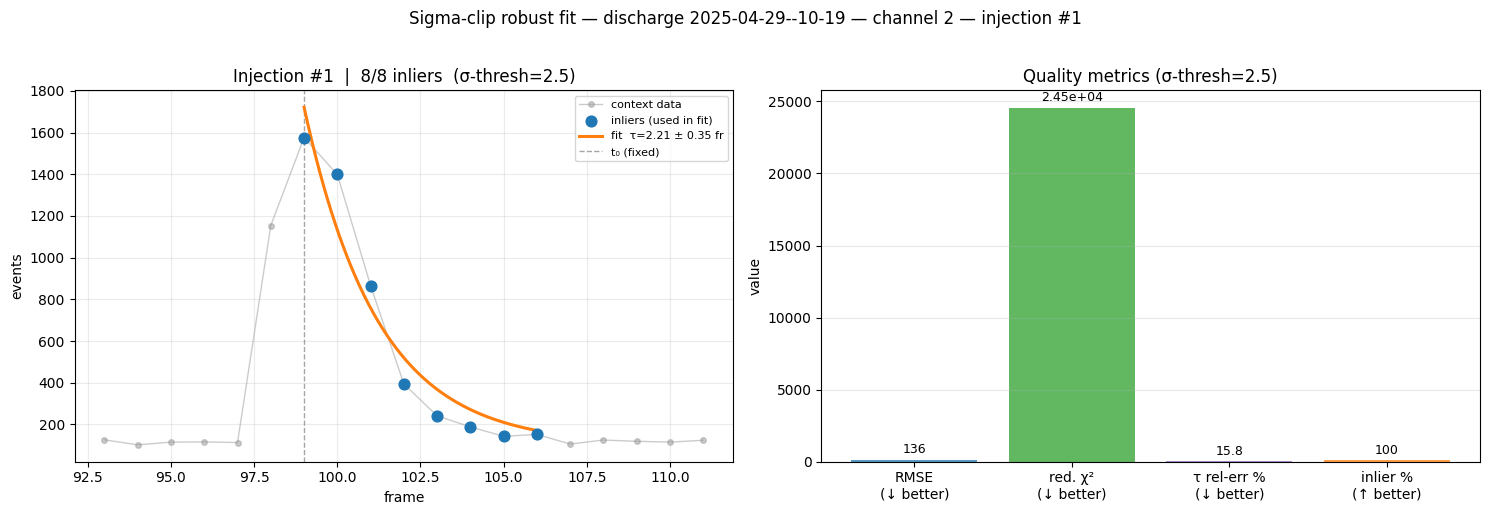

In [5]:
"""Cell 5 — Visualization: show inliers/outliers and fit curve.

Two panels:
  Left  — the injection region with inlier/outlier points colour-coded
           and the fitted curve drawn over ALL injection frames.
  Right — bar chart of the four quality metrics for sigma_thresh=2.5.
"""

if not result["success"]:
    print("No successful fit to plot.")
else:
    fn  = trace.frame_numbers
    v   = trace.values
    t_all      = result["t_all"]
    y_all      = result["y_all"]
    inlier_mask = result["inlier_mask"]

    A, tau, t_0, C_bg = result["A"], result["tau"], result["t_0"], result["C_bg"]

    # dense curve for plotting
    t_curve = np.linspace(float(t_all[0]), float(t_all[-1]), 300)
    y_curve = _exp_model(t_curve, A, tau, t_0, C_bg)

    # slightly wider context window
    ctx_lo = max(0, injection.start_frame - 5)
    ctx_hi = min(int(fn[-1]), injection.finish_frame + 5)
    ctx_mask = (fn >= ctx_lo) & (fn <= ctx_hi)

    fig, (ax_fit, ax_metrics) = plt.subplots(1, 2, figsize=(15, 5))

    # ---- left panel: fit + inlier/outlier annotation ----
    # background context (grey, faint)
    ax_fit.plot(fn[ctx_mask], v[ctx_mask], "o-", ms=4, lw=1,
                color="0.6", alpha=0.5, zorder=1, label="context data")

    # inliers (blue circles)
    ax_fit.scatter(t_all[inlier_mask], y_all[inlier_mask],
                   s=60, color="tab:blue", zorder=4, label="inliers (used in fit)")

    # outliers (red X)
    if (~inlier_mask).any():
        ax_fit.scatter(t_all[~inlier_mask], y_all[~inlier_mask],
                       s=80, marker="x", color="tab:red", linewidths=2,
                       zorder=5, label="outliers (sigma-clipped)")

    # fitted curve
    ax_fit.plot(t_curve, y_curve, color="tab:orange", lw=2.2, zorder=3,
                label=f"fit  τ={tau:.2f} ± {result['tau_err']:.2f} fr")

    ax_fit.axvline(injection.start_frame + 1, color="gray", ls="--", lw=1,
                   alpha=0.7, label="t₀ (fixed)")
    ax_fit.set_xlabel("frame")
    ax_fit.set_ylabel("events")
    ax_fit.set_title(f"Injection #{injection.injection_no}  |  "
                     f"{result['n_inliers']}/{result['n_total']} inliers  "
                     f"(σ-thresh=2.5)")
    ax_fit.legend(fontsize=8)
    ax_fit.grid(alpha=0.25)

    # ---- right panel: metric bar chart ----
    metric_names  = ["RMSE\n(↓ better)", "red. χ²\n(↓ better)",
                     "τ rel-err %\n(↓ better)", "inlier %\n(↑ better)"]
    metric_values = [
        result["rmse_inliers"],
        result["reduced_chi2"],
        result["tau_err_rel"] * 100,
        result["inlier_fraction"] * 100,
    ]
    colors = ["tab:blue", "tab:green", "tab:purple", "tab:orange"]
    bars = ax_metrics.bar(metric_names, metric_values, color=colors, alpha=0.75)
    for bar, val in zip(bars, metric_values):
        ax_metrics.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(metric_values) * 0.01,
                        f"{val:.3g}", ha="center", va="bottom", fontsize=9)
    ax_metrics.set_title("Quality metrics (σ-thresh=2.5)")
    ax_metrics.set_ylabel("value")
    ax_metrics.grid(axis="y", alpha=0.3)

    fig.suptitle(
        f"Sigma-clip robust fit — discharge 2025-04-29--10-19 — "
        f"channel {CHANNEL_ID} — injection #{injection.injection_no}",
        y=1.02, fontsize=12,
    )
    fig.tight_layout()
    plt.show()
